# Spam prediction

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [24]:
df=pd.read_csv('spam.csv',encoding='latin-1')

In [25]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [26]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

In [27]:
df.shape

(5572, 2)

In [28]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [29]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [30]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = re.sub(r'\d+', '', text)
    return text

df['message'] = df['message'].apply(clean_text)

In [31]:
df['clean_message'] = df['message'].apply(clean_text)

In [32]:
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['message'])

In [33]:
le = LabelEncoder()
y = le.fit_transform(df['label'])   # ham=0, spam=1

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

MultinomialNB()

In [36]:
y_pred = model.predict(X_test)

In [37]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


Accuracy : 0.9704035874439462
Precision: 0.8726114649681529
Recall   : 0.9133333333333333
F1 Score : 0.8925081433224755


In [38]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       965
           1       0.87      0.91      0.89       150

    accuracy                           0.97      1115
   macro avg       0.93      0.95      0.94      1115
weighted avg       0.97      0.97      0.97      1115



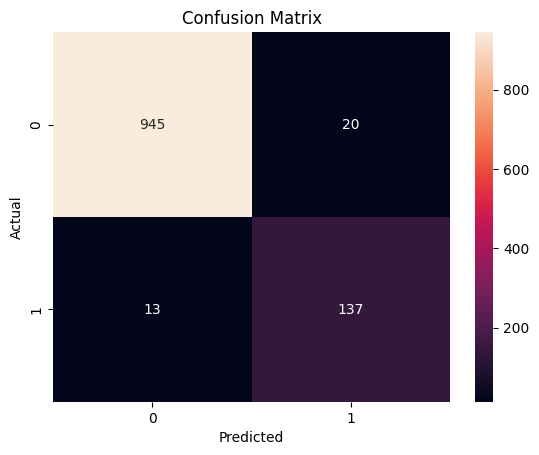

In [39]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
misclassified_indices = np.where(y_test != y_pred)[0]

print("Number of Misclassified Messages:", len(misclassified_indices))

print("\nSome Misclassified Examples:\n")

print(df.iloc[misclassified_indices][['label','message']].head())

Number of Misclassified Messages: 33

Some Misclassified Examples:

    label                                            message
0     ham  go until jurong point crazy available only in ...
32    ham                       k tell me anything about you
81    ham                     k did you call me just now ah 
86    ham  for real when u getting on yo i only need  mor...
100   ham  okay name ur price as long as its legal wen ca...


In [41]:
model_no_smooth = MultinomialNB(alpha=0.0)
model_no_smooth.fit(X_train, y_train)
y_pred_no = model_no_smooth.predict(X_test)

print("\nAccuracy without smoothing:",
      accuracy_score(y_test, y_pred_no))

print("Accuracy with smoothing:",
      accuracy_score(y_test, y_pred))


Accuracy without smoothing: 0.9309417040358744
Accuracy with smoothing: 0.9704035874439462


/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py:898: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(


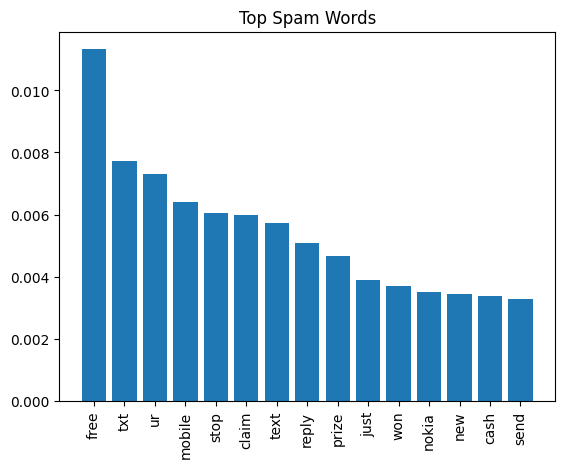

In [42]:
# Top Words Influencing Spam

feature_names = vectorizer.get_feature_names_out()#Extracts all words learned during CountVectorizer training.
spam_prob = np.exp(model.feature_log_prob_[1])

top_words = pd.DataFrame({
    "Word": feature_names,
    "Importance": spam_prob
}).sort_values(by="Importance",
               ascending=False).head(15)

plt.figure()
plt.bar(top_words["Word"], top_words["Importance"])
plt.xticks(rotation=90)
plt.title("Top Spam Words")
plt.show()

In [43]:
# Make sure vectorizer and model are aligned
print("Feature names:", len(vectorizer.get_feature_names_out()))
print("Model features:", model.feature_log_prob_.shape[1])

Feature names: 8293
Model features: 8293


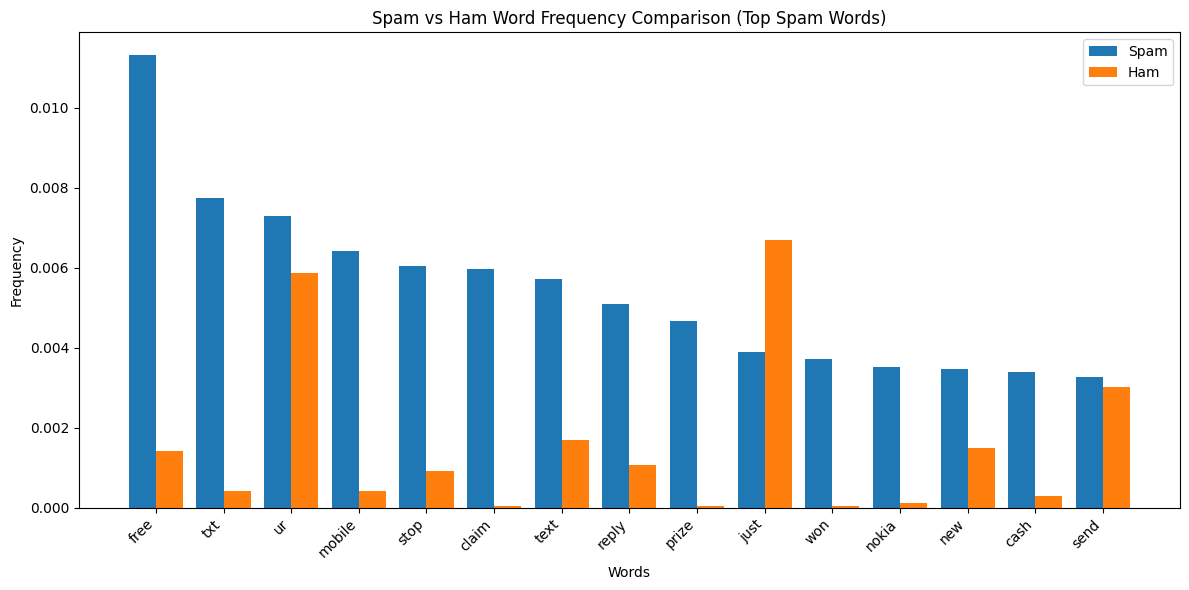

In [45]:
feature_names = vectorizer.get_feature_names_out()
spam_prob_all = np.exp(model.feature_log_prob_[1])
ham_prob_all = np.exp(model.feature_log_prob_[0])

# Create a DataFrame for all word probabilities
all_word_probs = pd.DataFrame({
    "word": feature_names,
    "spam": spam_prob_all,
    "ham": ham_prob_all
})

# Get the top spam words from the previously generated 'top_words' DataFrame
# and filter the all_word_probs to include only these words.
# We sort by 'spam' to maintain the order of top spam words.
comparison_df = all_word_probs[all_word_probs['word'].isin(top_words["Word"])].sort_values(by='spam', ascending=False).head(15)

plt.figure(figsize=(12, 6))

x_indices = np.arange(len(comparison_df))

plt.bar(x_indices - 0.2, comparison_df['spam'], width=0.4, label='Spam')
plt.bar(x_indices + 0.2, comparison_df['ham'], width=0.4, label='Ham')

plt.xticks(x_indices, comparison_df['word'], rotation=45, ha='right')

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Spam vs Ham Word Frequency Comparison (Top Spam Words)")

plt.legend()
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()